In [9]:
import sys
from pathlib import Path

class ImportMyModules:

    def __init__(self) -> None:
        self.cwd = Path.cwd().resolve()

    def _get_repo_root(self, folder: str) -> Path:
        return next(
            parent for parent in [self.cwd, *self.cwd.parents]
            if (parent / "lib" / "peregrin" / folder).exists()
        )

    def insert_path(self, folder: str) -> None:
        repo_root = self._get_repo_root("src")

        package_root = repo_root / "lib" / "peregrin"
        print(f"Adding {package_root} to sys.path")
        sys.path.insert(0, str(package_root))

importer = ImportMyModules()
importer.insert_path("src")
importer.insert_path("data")

from importlib import reload

Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path
Adding C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin to sys.path


In [10]:
import src.loader.load as load_module
reload(load_module)
load_data = load_module.load_data

data = load_data(r"./dummy_cell_tracks.csv", {'id': 'track_id', 'x': 'x_coordinate', 'y': 'y_coordinate', 't': 'time_point'}, spatial_unit="micrometer", time_unit="second")

import src.compute.stats as stats_module
reload(stats_module)
stats = stats_module.stats

spots = stats.spots(data)
spots

track_id,time_point,x_coordinate,y_coordinate,set,track_uid,frame,distance,cum_track_length,cum_track_displacement,cum_straightness_ratio,cum_speed_mean,cum_mean_straight_line_speed,cum_forward_progression_linearity,direction,directional_change,cum_sum_directional_change,cum_mean_directional_change,cum_mean_directional_change_rate,cum_direction_mean,cum_direction_var
f64,f64,f64,f64,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,25.0,242.8987,57.809882,"""dummy_cell_tracks.csv""",0,0,null,null,null,null,null,null,null,null,null,null,null,null,null,null
1.0,26.0,245.228029,54.597547,"""dummy_cell_tracks.csv""",0,1,3.96798,3.96798,3.96798,1.0,3.96798,1.98399,0.5,-0.943409,null,null,null,null,-0.943409,0.0
1.0,27.0,249.827267,49.532794,"""dummy_cell_tracks.csv""",0,2,6.841398,10.809378,10.794222,0.998598,5.404689,3.598074,0.665732,-0.833531,6.295573,6.295573,6.295573,2.098524,-0.88847,0.001509
1.0,28.0,252.715365,45.316116,"""dummy_cell_tracks.csv""",0,3,5.110918,15.920296,15.889025,0.998036,5.306765,3.972256,0.748527,-0.970261,7.834063,14.129636,7.064818,1.766204,-0.915755,0.001749
1.0,29.0,253.585434,39.076147,"""dummy_cell_tracks.csv""",0,4,6.300336,22.220632,21.567548,0.970609,5.555158,4.31351,0.776487,-1.432255,26.470285,40.59992,13.533307,2.706661,-1.042861,0.026066
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
24.0,95.0,165.663738,651.145494,"""dummy_cell_tracks.csv""",23,73,6.204479,466.606803,433.355841,0.928739,6.391874,5.85616,0.916188,2.571644,18.846007,675.379179,9.380266,0.12676,1.639609,0.072347
24.0,96.0,160.947074,653.762386,"""dummy_cell_tracks.csv""",23,74,5.393981,472.000784,436.290539,0.924343,6.378389,5.817207,0.912018,2.635058,3.633354,679.012533,9.301542,0.124021,1.651899,0.07746
24.0,97.0,151.214694,656.336399,"""dummy_cell_tracks.csv""",23,75,10.067014,482.067798,439.679452,0.91207,6.427571,5.785256,0.900069,2.883033,14.207968,693.2205,9.367845,0.123261,1.665642,0.085232



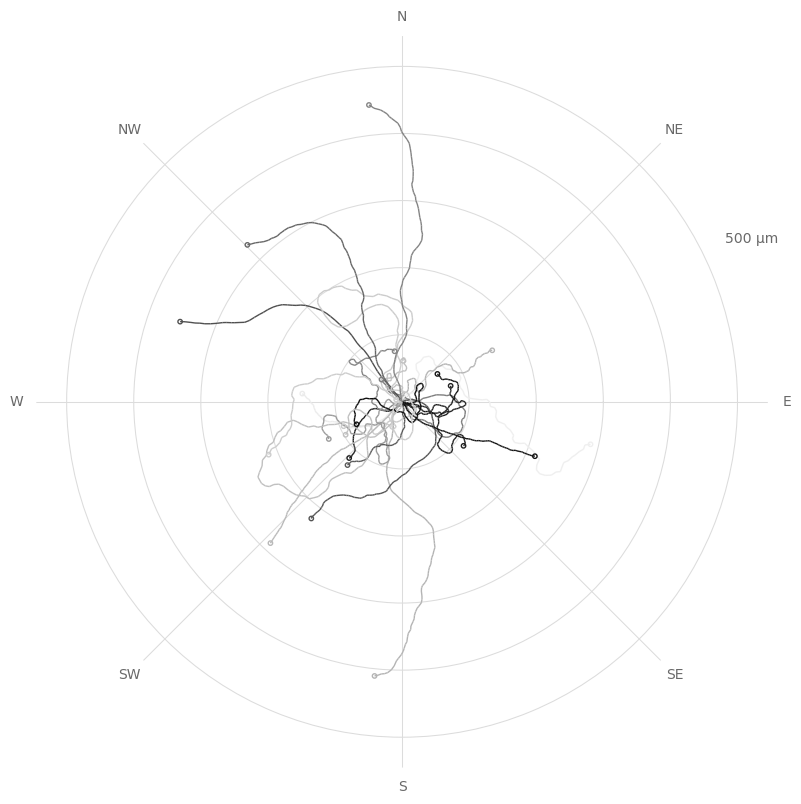

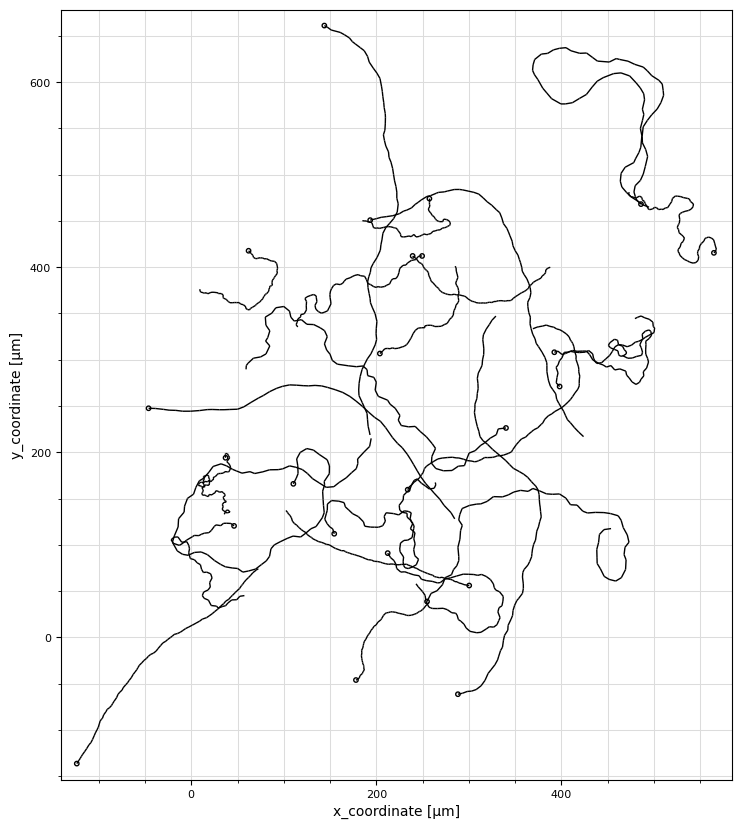

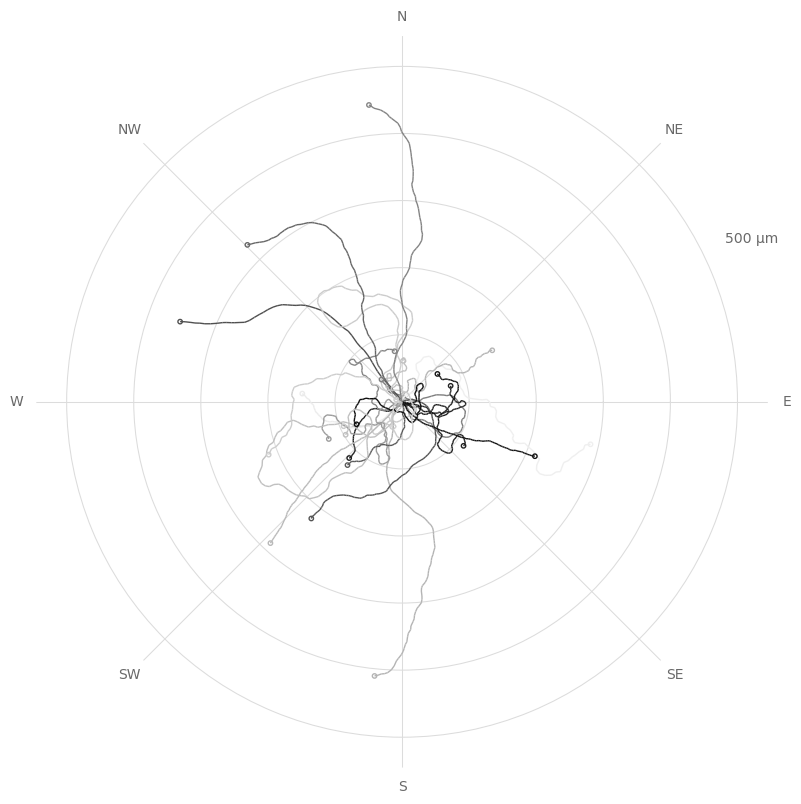

In [14]:
import src.plot.painter as painter_module
reload(painter_module)

import src.plot.tracks.reconstruct as reconstruct_module
reload(reconstruct_module)
reconstruct = reconstruct_module.reconstruct

reconstruct(spots)
reconstruct(spots, color='random greys', align_at_start=True)

C:\Users\modri\Desktop\Repositories\peregrin\lib\peregrin\src\plot\painter.py:288: ConflictingParametersWarning: Both 'color' and 'color_by' parameters are provided -> Parameter 'color' will be ignored -> Using 'color_by' for color assignment.
  return False



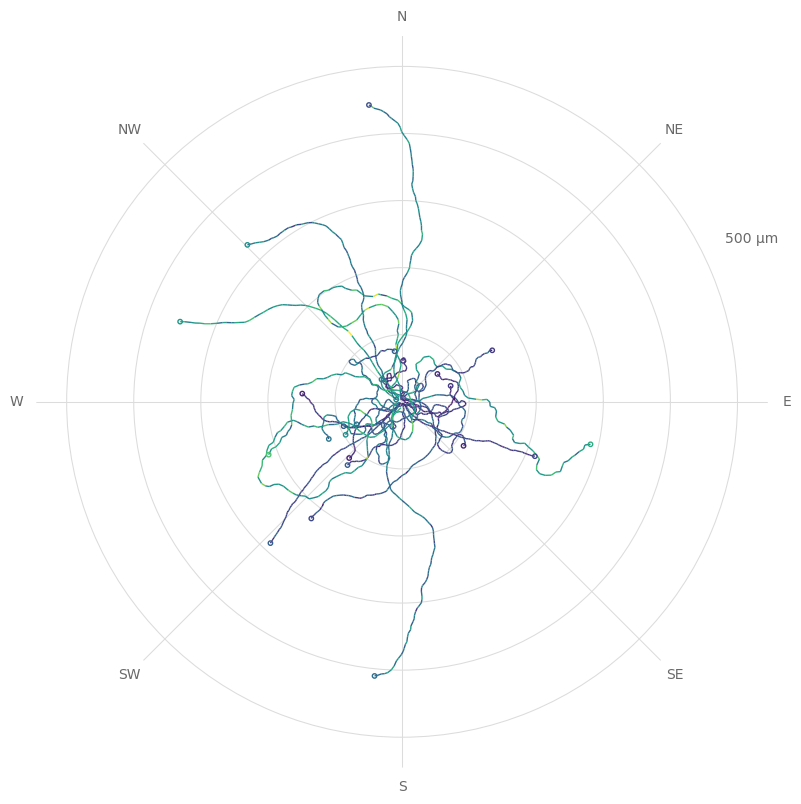

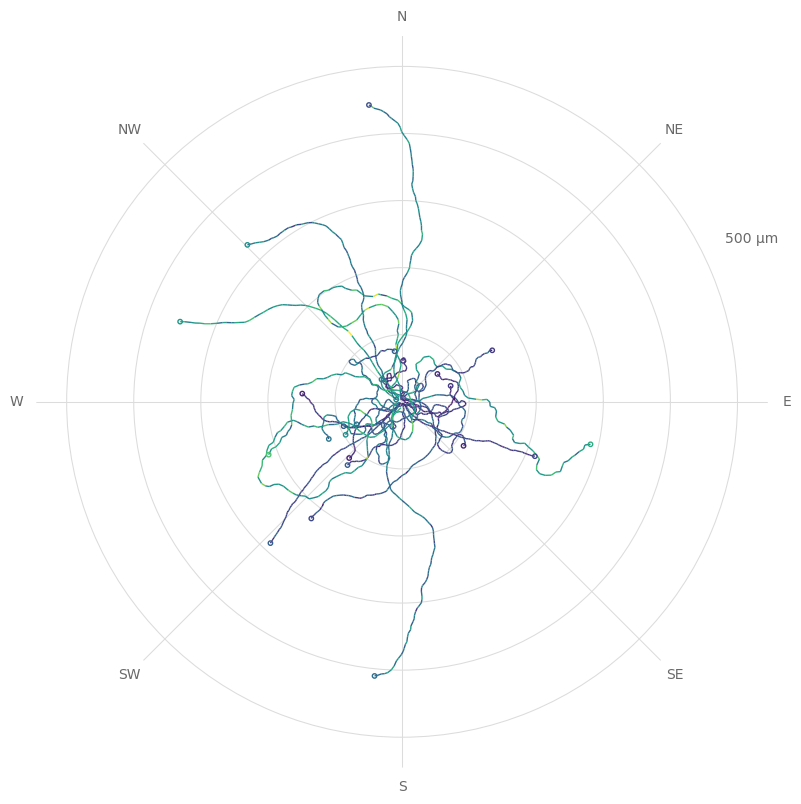

In [19]:
reconstruct(spots, color_by='distance', align_at_start=True)